# 02 · Sample Ratio Mismatch (SRM) & Novelty Effect

* SRM detection: a visual check, a χ² goodness-of-fit test, and a sequential SRM test (`ssrm-test`)
* Novelty effect: segment analysis and LinkedIn's regression-based detector ([arXiv:1808.00114](https://arxiv.org/pdf/1808.00114))

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import scipy.stats as stats


# 1. Data preparation
Datasets:
1. Sudden metric drop: date, group
2. SRM + SSRM: date, group, cif_id, metric -> an SRM problem occurs on some days of the test (on those days the A:B ratio is 40:60 instead of 50:50)
3. Novelty effect: date, metric, segment -> in one segment the metric changes at the start of the test, and then the effect fades

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta, date

# Parameters
start_date = date(2024, 5, 5)
days = 15
daily_users = [1154, 1351, 1254, 1200, 1300, 1100, 1400, 1300, 1250, 1150, 1200, 1300, 1250, 1350, 1200]
conversion_rate = 0.65  # Let's assume a 65% conversion rate

# Function to generate user data
def generate_data(start_date, days, daily_users):
    data = []
    current_cif_id = 1  # Start user ID

    for day in range(days):
        date_ = start_date + timedelta(days=day)
        n_users = daily_users[day]

        if day < 5:
            prob_b = 0.5
        elif 5 <= day <= 7:
            prob_b = 0.6
        else:
            prob_b = 0.5

        # Random group assignment using Bernoulli distribution
        group_assignment = np.random.binomial(1, prob_b, n_users)

        for i in range(n_users):
            group = 'B' if group_assignment[i] == 1 else 'A'
            metric = 1 if np.random.rand() < conversion_rate else 0
            data.append([date_, group, current_cif_id, metric])
            current_cif_id += 1

    return data

# Generate the dataset
data = generate_data(start_date, days, daily_users)

# Convert to a DataFrame
df = pd.DataFrame(data, columns=['date', 'group', 'cif_id', 'metric'])
df['date'] = pd.to_datetime(df['date'])
df

,date,group,cif_id,metric
0,2024-05-05,A,1,0
1,2024-05-05,B,2,1
2,2024-05-05,B,3,1
3,2024-05-05,A,4,0
4,2024-05-05,B,5,1
...,...,...,...,...
18754,2024-05-19,A,18755,1
18755,2024-05-19,B,18756,0
18756,2024-05-19,A,18757,0
18757,2024-05-19,B,18758,1


# 2. SRM

### 2.1. Visual check

In [ ]:
df.value_counts('group')

,count
group,
B,9754
A,9005


In [ ]:
df.value_counts('group', normalize=True)

,proportion
group,
B,0.519964
A,0.480036


In [ ]:
df_agg = df.groupby(['date', 'group'])['cif_id'].nunique().reset_index()
df_agg['date'] = pd.to_datetime(df_agg['date'])

<Axes: xlabel='date', ylabel='cif_id'>

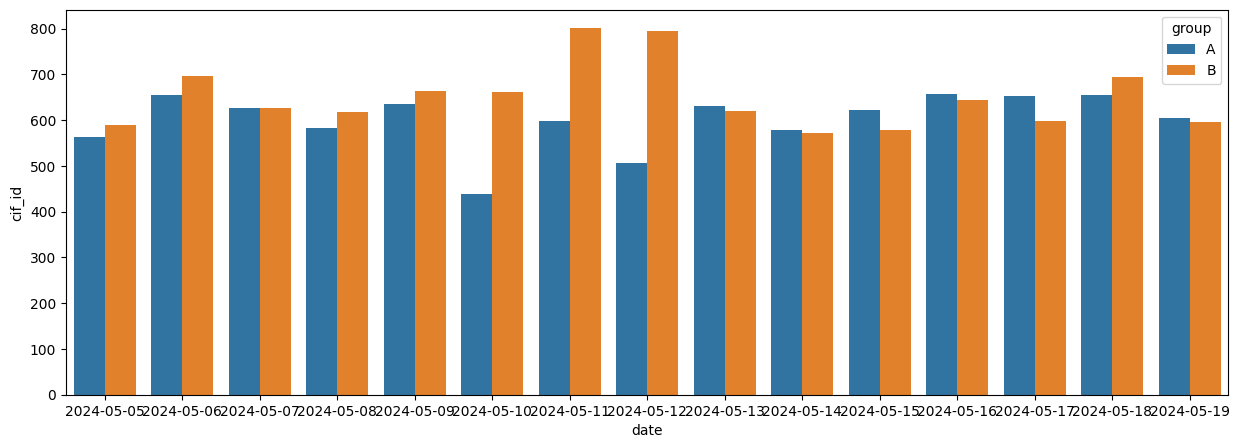

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(data=df_agg, x='date', y='cif_id', hue='group')

### 2.2. Chi-test check

In [ ]:
ratio = 0.5
fact_ratios =  [sum(df['group'] == 'A'), sum(df['group'] == 'B')]
estimated_ratios =  [len(df) * ratio, len(df) * (1 - ratio)]

chi_stat, p_val = stats.chisquare(fact_ratios, estimated_ratios)
p_val

4.535777722858514e-08

### 2.3. SSRM test

In [ ]:
!pip install ssrm-test

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for toolz: filename=toolz-0.10.0-py3-none-any.whl size=55567 sha256=842909f31bf65ea62dc6064937cebc3aca839221d520fa9c7fe14dd9299569c4
  Stored in directory: /root/.cache/pip/wheels/7f/98/e1/9f8a819bf3101a286390fcd81a23401960dc6467b521039af6
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26302 sha256=56db4068688382458771e2ee4dc93f10cc4b41acfd6ea159fc28697d74e5a116
  Stored in directory: /root/.cache/pip/wheels/7c/d0/9e/1f26ebb66d9e1732e4098bc5a6c2d91f6c9a529838f0284890
Successfully built toolz typing
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
ERROR: pip's dependency resolver does not currently take int

Stop at user #7221 (approximately day 6-7)


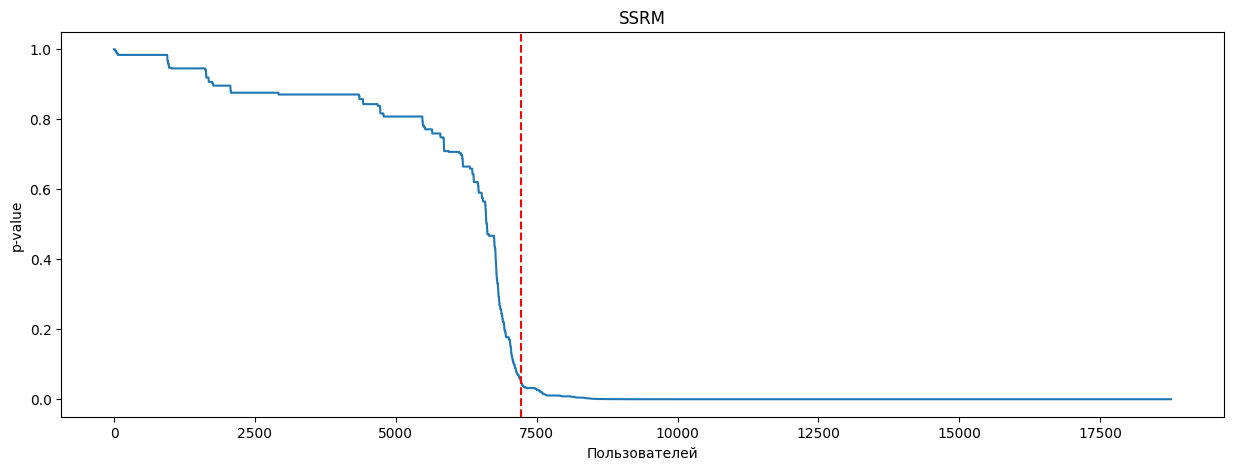

In [ ]:
from ssrm_test import ssrm_test

ssrm_df = pd.get_dummies(df['group'], columns=['group']).astype(int)

p_vals = ssrm_test.sequential_p_values(ssrm_df, [0.5, 0.5])
p_vals = np.array(p_vals)
p_val_stop = np.argmax(p_vals < 0.05)

plt.figure(figsize=(15, 5))
plt.plot(p_vals)
plt.axvline(p_val_stop, color='r', linestyle='--')
print(f"Stop at user #{p_val_stop} (approximately day 6-7)")


plt.title("SSRM")
plt.xlabel("Users")
plt.ylabel("p-value")
plt.show()

### 2. Novelty effect
date, metric, segment (A_ios, A_android, B_ios, B_android)
-> in one segment the metric changes at the start of the test, and then the effect fades


### 2.0. Data generation

In [ ]:
# generate data
periods = 21
effect = np.concatenate((np.linspace(-0.5, 0.15, periods // 2+1), np.array([0.15] * (periods//2))), axis=0)


A_old = np.random.normal(11, 0.02, periods)
B_old = np.random.normal(11, 0.05, periods) + effect

A_new = np.random.normal(10.5, 0.04, periods)
B_new = np.random.normal(10.57, 0.03, periods)

# x = pd.date_range(start='2019-01-01', freq='D', periods=periods)
x = range(1, periods+1)

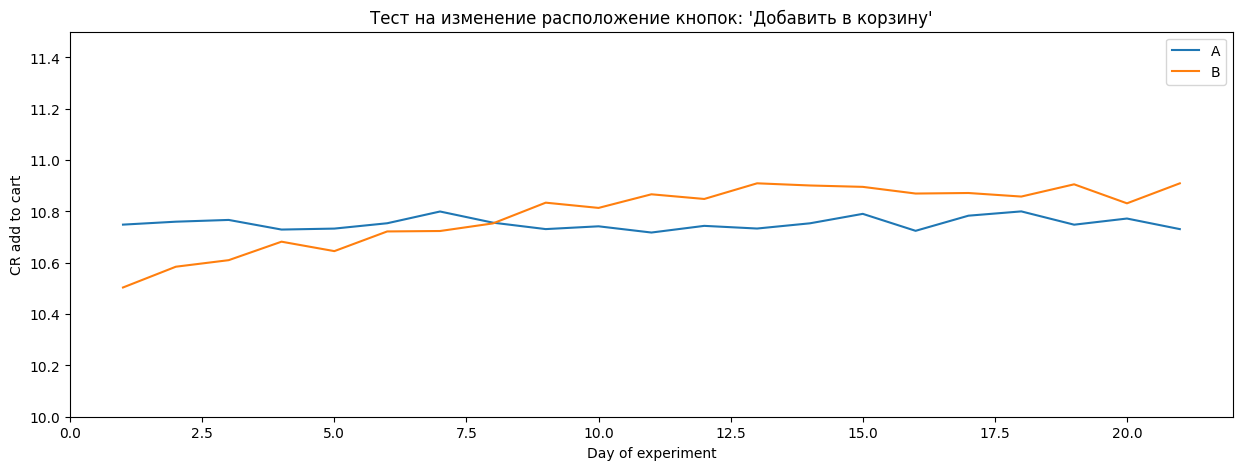

In [ ]:
plt.figure(figsize=(15, 5))

sample_A = (A_old + A_new) / 2
sample_B = (B_new + B_old) / 2

plt.plot(x, sample_A, label='A')
plt.plot(x, sample_B, label='B')

plt.title("Test of a new button placement: 'Add to cart'")
plt.legend()
plt.xlabel("Day of experiment")
plt.ylabel("CR add to cart")
plt.ylim([10, 11.5])
# plt.ylim(0, 20)

plt.show()

In [ ]:
import numpy as np
from scipy import stats

# Perform t-test
t_stat, p_value = stats.ttest_ind(sample_A, sample_B)

print(f'T-statistic: {t_stat}')
print(f'P-value: {p_value}')

T-statistic: -1.2670278974396325
P-value: 0.21247294293185198


### 2.1. Segmentation

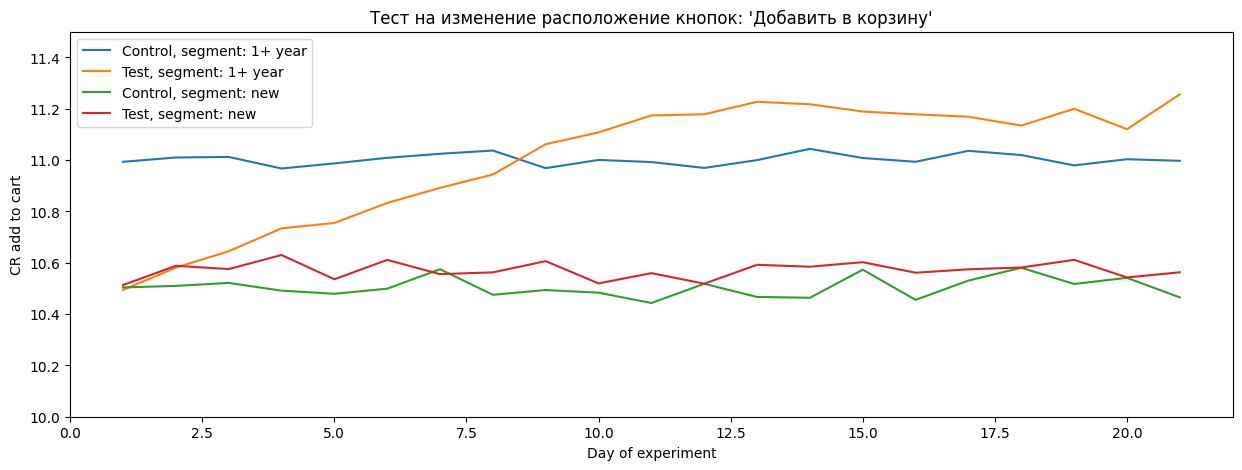

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(x, A_old, label='Control, segment: 1+ year')
plt.plot(x, B_old, label='Test, segment: 1+ year')
plt.plot(x, A_new, label='Control, segment: new')
plt.plot(x, B_new, label='Test, segment: new')

plt.title("Test of a new button placement: 'Add to cart'")
plt.legend()
plt.xlabel("Day of experiment")
plt.ylabel("CR add to cart")
plt.ylim([10, 11.5])
# plt.ylim(0, 20)

plt.show()

### 2.3. LinkedIn algorithm
https://arxiv.org/pdf/1808.00114

An algorithm that automatically detects a novelty effect in a test:
1. Align all users relative to their first day in the test
2. Compute the metric difference on day i => an array delta (length = number of days in the test)
3. Build two features:
    - X1 = 1 / t^alpha;
    - X2 = 1 / t^gamma;
    - target: y = delta[t],
    where t is the (relative) day of the experiment; alpha = 0.35, gamma = 2
4. Fit a linear regression on these features


In [ ]:
df = pd.DataFrame()
df['day_of_test'] = x
df['A_old'] = A_old
df['A_new'] = A_new
df['B_old'] = B_old
df['B_new'] = B_new

df

,day_of_test,A_old,A_new,B_old,B_new
0,1,10.993105,10.503756,10.494008,10.513033
1,2,11.010005,10.509728,10.580838,10.588024
2,3,11.012104,10.521335,10.644611,10.575271
3,4,10.967148,10.491227,10.733888,10.630038
4,5,10.986933,10.479019,10.754857,10.535517
5,6,11.008747,10.498794,10.832775,10.610956
6,7,11.024384,10.574726,10.891582,10.555547
7,8,11.037122,10.475108,10.943794,10.562492
8,9,10.968457,10.493541,11.061727,10.606232
9,10,11.000489,10.483244,11.107683,10.519411


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

alpha = 0.35
gamma = 2

df['x1'] = 1 / (df['day_of_test']**alpha)
df['x2'] = 1 / (df['day_of_test']**gamma)
df['delta'] = (df['B_old'] - df['A_old'])


X = df[['x1','x2']].values
y = df['delta'].values

# fit the linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y)

df['y_predict'] = lin_reg.predict(X)

# novelty effect assessment
r2 = r2_score(df['delta'].values, df['y_predict'].values)
print('R-square: ', r2)

R-square:  0.9202055484176561


A novelty effect is present if:
1. The regression predicts the actual lift values well (R-squared ≥ 0.8).
2. The fitted line (the model prediction) changes monotonically over time


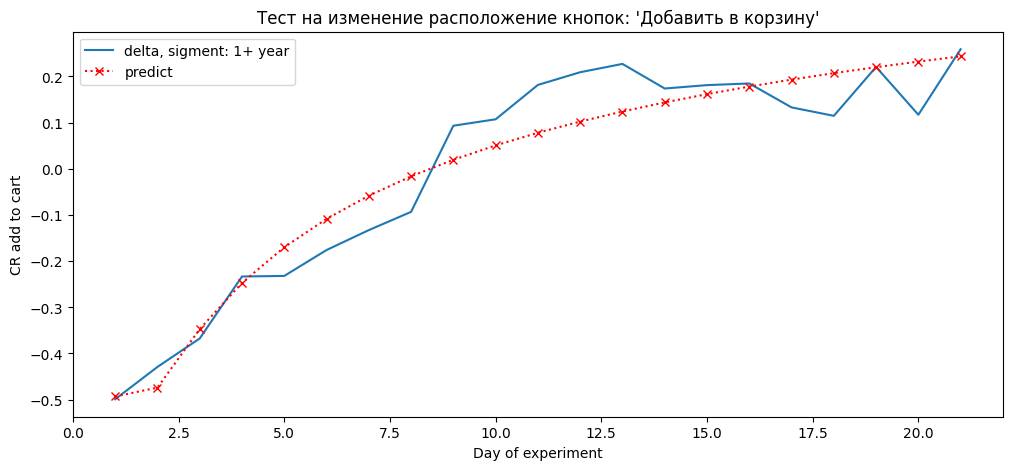

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(x, df['delta'], label='delta, sigment: 1+ year')
plt.plot(x, df['y_predict'], label='predict', linestyle=':', marker='x', color='red')

plt.title("Test of a new button placement: 'Add to cart'")
plt.legend()
plt.xlabel("Day of experiment")
plt.ylabel("CR add to cart")
# plt.ylim([10, 11.5])
# plt.ylim(0, 20)

plt.show()

### For comparison, repeat the same for new users


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

alpha = 0.35
gamma = 2

df['x1'] = 1 / (df['day_of_test']**alpha)
df['x2'] = 1 / (df['day_of_test']**gamma)
df['delta'] = (df['B_new'] - df['A_new'])


X = df[['x1','x2']].values
y = df['delta'].values

# fit the linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y)

df['y_predict'] = lin_reg.predict(X)

# novelty effect assessment
r2 = r2_score(df['delta'].values, df['y_predict'].values)
print('R-square: ', r2)

R-square:  0.0939606585347268


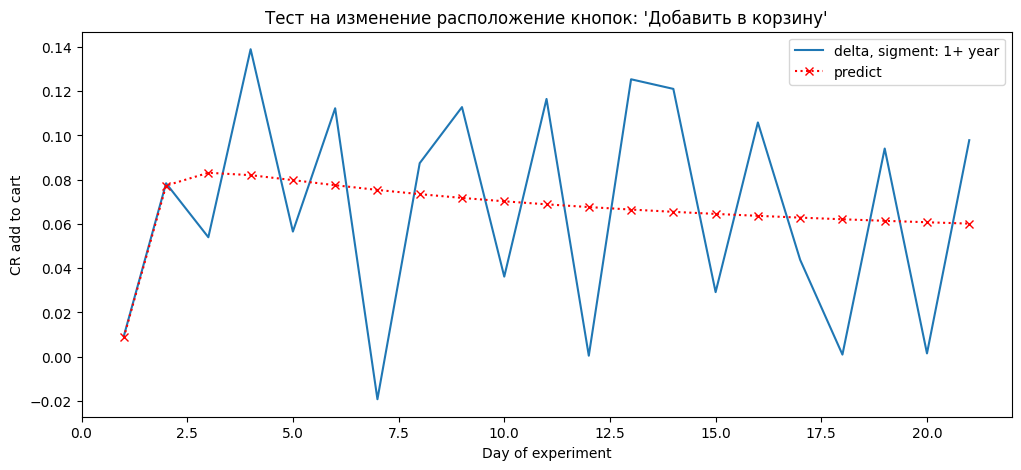

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(x, df['delta'], label='delta, sigment: 1+ year')
plt.plot(x, df['y_predict'], label='predict', linestyle=':', marker='x', color='red')

plt.title("Test of a new button placement: 'Add to cart'")
plt.legend()
plt.xlabel("Day of experiment")
plt.ylabel("CR add to cart")
# plt.ylim([10, 11.5])
# plt.ylim(0, 20)

plt.show()